# BactoCat Demonstration Notebook

This notebook demonstrates the main steps of the BactoCat workflow for
estimating enzyme catalytic capacity (kapp) from proteomics and metabolic
models.

The pipeline integrates:

* Proteomics datasets (Aida dataset)
* AMN-predicted fluxes
* Genome-scale metabolic models
* Enzyme–substrate mappings

The output of the pipeline is an estimate of the maximum apparent catalytic
rate $k_{app}$ for each enzyme–substrate pair.

This notebook demonstrates:

1. Preprocessing of the Aida proteomics dataset
2. Overview of Artificial Metabolic Networks (AMNs)
3. Execution of the BactoCat kapp pipeline
4. Comparison between predicted kapp and literature kcat values

## Set up environment

In [1]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Standard library imports
import os
import sys
from pathlib import Path
import pandas as pd
import yaml

# Load paths from config file
from src.config import *

print("Root directory:", PROJ_ROOT)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Root directory: /home/yuxiz/BactoCat
Data directory: /home/yuxiz/BactoCat/data
Results directory: /home/yuxiz/BactoCat/results


## 1. Aida Dataset Preprocessing

This step involves translating the experimental media compositions from the Aida & Ying (2025) dataset into a format compatible with Genome-Scale Metabolic Models (GEMs). 

The preprocessing performs:
- mapping proteomics proteins to GEM genes
- formatting experimental conditions
- preparing AMN-compatible media descriptions

Output:
processed proteomics datasets used for kapp estimation.

### 1.1 Import AIDA preprocessing functions and set paths

Change paths if needed

In [2]:
import cobra
cobra.Configuration().solver = "glpk"

from src.aida_preprocessing.aida_to_GEM import (
    create_supplementary_csv,
    create_media_growth_csv,
    match_amns_media
)

# Set paths for AIDA preprocessing
model_path = RAW_DATA_DIR / "gems" / "iml1515.xml"
media_input = RAW_DATA_DIR / "ecoli_aida_dataset" / "media_composition_original.csv"
growth_input = RAW_DATA_DIR / "ecoli_aida_dataset" / "growth_data.csv"
correction_dir = PROCESSED_DATA_DIR / "amns" / "correct_med_iml1515.csv"
output_dir = PROCESSED_DATA_DIR / "ecoli_aida_dataset"

output_dir.mkdir(parents=True, exist_ok=True)


### 1.2 Run AIDA preprocessing steps

* Maps compound names from the AIDA dataset to the "Exchange Reactions" in the GEM model
* Cleans up column names
* Takes the table of experimental concentrations (A) and multiplies it by the mapping matrix (M)
* Finds unique media compositions to reduce redundant simulations later

In [3]:
# Load GEM
model = cobra.io.read_sbml_model(str(model_path))

# Build AIDA → GEM mapping
mapping_csv = create_supplementary_csv(model, output_dir)

# Build media + growth dataset
final_df, media_output = create_media_growth_csv(
    media_input,
    growth_input,
    mapping_csv,
    output_dir
)

# Match media to AMNs and apply corrections
corrected_csv = match_amns_media(
    correction_dir,
    output_dir,
    final_df
)

print("Aida preprocessing finished.")
print("Media CSV:", media_output)
print("Corrected AMN media:", corrected_csv)

2026-03-19 12:30:38.742 | INFO     | src.aida_preprocessing.aida_to_GEM:create_supplementary_csv:80 - Total AIDA compounds in mapping: 40
2026-03-19 12:30:38.867 | INFO     | src.aida_preprocessing.aida_to_GEM:create_media_growth_csv:150 - Mapped 40 AIDA columns into 37 GEM reactions.
2026-03-19 12:30:38.868 | INFO     | src.aida_preprocessing.aida_to_GEM:create_media_growth_csv:151 - 6 media columns were not mapped.
2026-03-19 12:30:38.869 | INFO     | src.aida_preprocessing.aida_to_GEM:create_media_growth_csv:152 - Columns not renamed: ['Label', 'Assay ID', 'FolicAcid (mM)', 'Riboflavin (mM)', 'H3BO3 (mM)', 'AminobenzoicAcid (mM)']
2026-03-19 12:30:38.920 | INFO     | src.aida_preprocessing.aida_to_GEM:create_media_growth_csv:165 - Media compositions before dropping duplicates → 13608
2026-03-19 12:30:39.041 | INFO     | src.aida_preprocessing.aida_to_GEM:create_media_growth_csv:167 - Unique media compositions after dropping duplicates → 941
2026-03-19 12:30:39.041 | INFO     | src.a

Aida preprocessing finished.
Media CSV: /home/yuxiz/BactoCat/data/processed/ecoli_aida_dataset/ecoli_aida_media_growth.csv
Corrected AMN media: /home/yuxiz/BactoCat/data/processed/ecoli_aida_dataset/corrected_media_compositions.csv


## 2. AMNs

**AMNs** are used to bridge the gap between experimental media compositions ($C_{med}$) and metabolic flux predictions ($V_{in}$). This addresses the "unknown uptake flux problem" in Constraint-Based Modeling by embedding a metabolic model within a machine learning architecture.

*   **The Media Network:** A trainable neural layer predicts uptake flux bounds ($V_{in}$) from the nutrient presence.
*   **The Frozen Reservoir:** An AMN pre-trained on FBA simulations that mimics an FBA solver, ensuring predictions adhere to stoichiometric constraints.
*   **Output:** The primary output is a predicted complete flux vector or specific uptake fluxes ($V_{in}$) used to constrain subsequent GEM simulations.

Input -- experimental media compositions ($C_{med}$) ($mM$)​

Output -- metabolic flux predictions ($V_{in}$) ($mmol/(gDCW h)^{-1}$) 

Repo for AMNs: https://github.com/lyach/BactoCat-AMN

## 3. Run Bactocat 

This pipeline builds enzyme kinetic datasets by integrating predicted fluxes with protein abundance data. It systematically executes the following core steps:

*   Create GPR dataframes and map organisms to UniProt sequences.
*   (Optional): Run **Flux Variability Analysis (FVA)** to assess the range of feasible fluxes.
*   Build fluxomics and enzyme info dataframes, and process enzyme-protein mappings.
*   Calculate **$k_{max}$** (the maximal in vivo $k_{app}$) across all conditions for homomeric enzymes.


### 3.1 Load YAML configuration

Change the paths in "ecoli_homomeric.yaml" if needed

In [4]:
from src.config import load_config
from pathlib import Path

config_path = PROJ_ROOT / "configs" / "run_kapp_pipeline" / "ecoli_homomeric.yaml"

config = load_config(config_path)

print(config)

organism='ecoli' folder_id='ecoli_homomeric' model_path=PosixPath('/home/yuxiz/BactoCat/data/raw/gems/iml1515.xml') solver='cplex' flux_method='pFBA' carbon_uptake=[2.0, 6.0, 10.0] oxygen_uptake=[15.0, 17.5, 20.0] carbon_exchange_rxn='EX_glc__D_e' oxygen_exchange_rxn='EX_o2_e' mu_fraction=0.9 medium_df=None run_fva=False p_total=0.55 paxdb_path=PosixPath('/home/yuxiz/BactoCat/data/raw/paxdb/ecoli_whole_organism_integrated_511145.txt') substrate_df=PosixPath('/home/yuxiz/BactoCat/data/processed/substrates/iml1515_substrates.csv') sequence_df=PosixPath('/home/yuxiz/BactoCat/data/processed/uniprot/ecoli_uniprot_seqs.csv') upper_threshold=1000000.0 lower_threshold=1e-05 calculate_eta=True


### 3.2 Set output paths

Change paths if needed

In [5]:
# Set folder name
run_name = f"{config.organism}_{config.folder_id}"

# Create output directories
results_base = PROJ_ROOT / "results" / "run_kapp_pipeline"
run_root = results_base / run_name
output_dir = ensure_dir_exists(run_root / "results")
data_dir = ensure_dir_exists(run_root / "data")

### 3.3 Create GEM enzymes dataframe

Parse the model's Gene-Protein-Reaction (GPR) rules. Identifies which genes encode which proteins and which specific chemical reactions they catalyze.

In [6]:
from scripts.run_kapp_pipeline import (create_gpr_dataframe, analyze_model_gprs)

df_enzymes = create_gpr_dataframe(model)

stats = analyze_model_gprs(model)
print(f"Total reactions: {stats['total_reactions']}")
print(f"Reactions with GPR: {stats['reactions_with_gpr']}")
print(f"Total genes: {stats['total_genes']}")
print(f"GPR cases: {stats['gpr_complexity']}")

Total reactions: 2712
Reactions with GPR: 2266
Total genes: 1516
GPR cases: {'simple': 1302, 'or_only': 651, 'and_only': 221, 'complex': 92}


### 3.4 Fluxomics Simulations

Using pFBA (Parsimonious Flux Balance Analysis), the pipeline simulates the metabolic fluxes under different environmental conditions (e.g., varying glucose and oxygen levels).

In [7]:
from scripts.run_kapp_pipeline import create_fluxomics_dataframe
medium_df_loaded = pd.read_csv(config.medium_df) if config.medium_df else None
# 1. Load the experimental media conditions if they exist
medium_df_loaded = None
if config.medium_df is not None and config.medium_df.exists():
    try:
        medium_df_loaded = pd.read_csv(config.medium_df)
        print(f"Medium dataframe loaded: {len(medium_df_loaded)} conditions from {config.medium_df.name}")
    except Exception as e:
        raise ValueError(f"Error loading medium_df from {config.medium_df}: {e}")
    
# 2. Run the simulation
# This will use pFBA (Parsimonious Flux Balance Analysis) by default 
# to find the most efficient metabolic path for each condition.
fluxomics_df = create_fluxomics_dataframe(
    flux_method=config.flux_method,          # e.g., 'pfba'
    GEM=model,                              # Your loaded cobra model
    carbon_uptake=config.carbon_uptake,     # List of rates if not using medium_df
    oxygen_uptake=config.oxygen_uptake,     # List of rates if not using medium_df
    carbon_exchange_rxn=config.carbon_exchange_rxn, # e.g., 'EX_glc__D_e'
    oxygen_exchange_rxn=config.oxygen_exchange_rxn, # e.g., 'EX_o2_e'
    medium_df=medium_df_loaded,             # The mapped Aida media data
)

# 3. Inspect the results
print(f"Generated fluxomics dataframe with shape: {fluxomics_df.shape}")
fluxomics_df.head()

2026-03-19 12:30:46.073 | INFO     | src.kapp_builder:create_fluxomics_dataframe:134 - Using given carbon/oxygen combinations for flux simulations


Flux conditions: 100%|██████████| 9/9 [00:05<00:00,  1.61cond/s]
2026-03-19 12:30:51.681 | INFO     | src.kapp_builder:create_fluxomics_dataframe:186 - Fluxomics dataframe created with 9 conditions


Generated fluxomics dataframe with shape: (2712, 10)


,rxn_id,flux_cond1,flux_cond2,flux_cond3,flux_cond4,flux_cond5,flux_cond6,flux_cond7,flux_cond8,flux_cond9
0,ALATA_D2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,SHCHD2,0.000035,0.000035,0.000035,0.000115,0.000115,0.000115,0.000154,0.000169,0.000183
2,CPPPGO,0.000035,0.000035,0.000035,0.000115,0.000115,0.000115,0.000154,0.000169,0.000183
3,GTHOr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,DHORD5,0.000252,0.000252,0.000252,0.000839,0.000000,0.000000,0.000000,0.000000,0.000000


### 3.5 Flux Variability Analysis (Optional)

An optional "sanity check." It determines the minimum and maximum possible flux for every reaction. If a simulated flux from Step 3.5 falls outside these physical bounds, it is flagged as a violation. 

Default is run_fva: false

In [8]:
from scripts.run_kapp_pipeline import create_FVA_dataframe, FVA_integration
# 1. Validation & Setup
# If medium_df_loaded is None, we must provide manual uptake rates from config
if not config.run_fva:
    print("Skipping flux variability analysis (run_fva=false)")
    filtered_fluxomics_df = fluxomics_df.copy()
else:
    print("Running flux variability analysis")
    try:
        # 2. Run FVA
        # This step is computationally expensive because it runs two optimizations 
        # (min and max) for every single reaction in the model.
        fva_df = create_FVA_dataframe(
            GEM_path=str(config.model_path),
            carbon_uptake=config.carbon_uptake,
            oxygen_uptake=config.oxygen_uptake,
            mu_fraction=config.mu_fraction,              # Percentage of max growth to maintain
            solver=config.solver,
            carbon_exchange_rxn=config.carbon_exchange_rxn,
            oxygen_exchange_rxn=config.oxygen_exchange_rxn,
            medium_df=medium_df_loaded
        )
        print("FVA dataframe created successfully")

        print("Integrating FVA results with fluxomics data")
        # 3. Integrate and Filter
        # This compares pFBA results against these FVA bounds.
        # It 'filters' out any conditions where the pFBA result was mathematically impossible.
        filtered_fluxomics_df, violations_df = FVA_integration(fluxomics_df, fva_df, filter=True)
        fva_df.to_csv(output_dir / f"FVA_bounds_{run_name}.csv", index=False)
        filtered_fluxomics_df.to_csv(output_dir / f"fluxomics_filtered_{run_name}.csv", index=False)
        violations_df.to_csv(output_dir / f"FVA_violations_{run_name}.csv", index=False)

        print(f"FVA integration complete. Filtered fluxomics: {filtered_fluxomics_df.shape[0]} rows")
        print(f"Violations detected: {violations_df.shape[0]} rows")
    except Exception as e:
        raise RuntimeError(f"Error during FVA integration: {e}")

fluxomics_df = filtered_fluxomics_df.copy()



Skipping flux variability analysis (run_fva=false)


### 3.6 Load Sequence and Substrate Info

Load Sequence Information: Fetches amino acid sequences (often from UniProt). Used to calculate the molecular weight of the enzymes. 

Load Substrate Information: Identifies which metabolites are the substrates for each enzyme.

In [9]:
from scripts.run_kapp_pipeline import map_organism_to_uniprot
from scripts.run_kapp_pipeline import get_substrate_df

# Load sequence information
if config.sequence_df and config.sequence_df.exists():
    try:
        sequence_df_loaded = pd.read_csv(config.sequence_df)
        print(f"Sequence dataframe loaded: {len(sequence_df_loaded)} rows")
    except Exception as e:
        raise ValueError(f"Sequence dataframe not found at {config.sequence_df}. Error: {e}")
else:
    print("No sequence dataframe provided, retrieving sequences from UniProt")
    sequence_df_loaded = map_organism_to_uniprot(config.organism)
    seq_output = data_dir / f"{config.organism}_uniprot_seqs.csv"
    sequence_df_loaded.to_csv(seq_output, index=False)
    print(f"Sequence dataframe created: {len(sequence_df_loaded)} rows at {seq_output.name}")

Sequence dataframe loaded: 1516 rows


In [10]:
# Load substrate information
if config.substrate_df and config.substrate_df.exists():
    try:
        substrate_df_loaded = pd.read_csv(config.substrate_df)
        print(f"Substrate dataframe loaded: {len(substrate_df_loaded)} rows")
    except Exception as e:
        raise ValueError(f"Substrate dataframe not found at {config.substrate_df}. Error: {e}")
else:
    print("No substrate dataframe provided, generating from model")
    substrate_df_loaded = get_substrate_df(model)
    sub_output = data_dir / f"{config.organism}_substrate_df.csv"
    substrate_df_loaded.to_csv(sub_output, index=False)
    print(f"Substrate dataframe created: {len(substrate_df_loaded)} rows at {sub_output.name}")

Substrate dataframe loaded: 6194 rows


### 3.7 Merge Data and Map Proteomics

Create Enzyme Information Dataframe: Merges the flux data with the sequence and substrate data into a single master table.

Map Proteomics Information: Imports protein abundance measurements (from PaxDB). Tells the pipeline exactly how many copies of an enzyme were present during the experiment.

In [11]:
from scripts.run_kapp_pipeline import create_enzyme_info_dataframe, process_enzyme_protein_mapping

# Create the master info DF
enzymes_info_dfs = create_enzyme_info_dataframe(df_enzymes, fluxomics_df, substrate_df_loaded, sequence_df_loaded)

# Map PaxDB/Proteomics data
enzyme_protein_info_dfs = process_enzyme_protein_mapping(
    enzymes_info_dfs, str(config.paxdb_path), p_total=config.p_total
)

2026-03-19 12:30:53.766 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:571 - Processing flux_cond1...
2026-03-19 12:30:53.767 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:572 -  Rows before filtering: 4624
2026-03-19 12:30:53.768 | WARNING  | src.kapp_builder:create_enzyme_info_dataframe:587 - Warning: Missing FVA columns for flux_cond1 — skipping FVA merge.
2026-03-19 12:30:53.797 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:660 -   flux_cond1: 1168 rows after filtering
2026-03-19 12:30:53.798 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:571 - Processing flux_cond2...
2026-03-19 12:30:53.798 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:572 -  Rows before filtering: 4624
2026-03-19 12:30:53.799 | WARNING  | src.kapp_builder:create_enzyme_info_dataframe:587 - Warning: Missing FVA columns for flux_cond2 — skipping FVA merge.
2026-03-19 12:30:53.814 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:660 -   flux_c

2026-03-19 12:30:53.816 | WARNING  | src.kapp_builder:create_enzyme_info_dataframe:587 - Warning: Missing FVA columns for flux_cond3 — skipping FVA merge.
2026-03-19 12:30:53.832 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:660 -   flux_cond3: 1168 rows after filtering
2026-03-19 12:30:53.833 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:571 - Processing flux_cond4...
2026-03-19 12:30:53.833 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:572 -  Rows before filtering: 4624
2026-03-19 12:30:53.834 | WARNING  | src.kapp_builder:create_enzyme_info_dataframe:587 - Warning: Missing FVA columns for flux_cond4 — skipping FVA merge.
2026-03-19 12:30:53.849 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:660 -   flux_cond4: 1157 rows after filtering
2026-03-19 12:30:53.850 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:571 - Processing flux_cond5...
2026-03-19 12:30:53.850 | DEBUG    | src.kapp_builder:create_enzyme_info_dataframe:572

### 3.8  Calculate and Filter $k_{app}$

Calculates the Apparent Catalytic Rate ($k_{app}$) using the formula:$$k_{app} = \frac{\text{Metabolic Flux}}{\text{Protein Abundance}}$$ 

$k_{app}$ values that are physically impossible (e.g., rates faster than the laws of diffusion allow) are removed.

In [12]:
from scripts.run_kapp_pipeline import calculate_kapp_homomeric, evaluate_kapp_homomeric

kapp_dfs = calculate_kapp_homomeric(enzyme_protein_info_dfs)
kapp_dfs_filtered = evaluate_kapp_homomeric(kapp_dfs)

2026-03-19 12:30:54.562 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond1: 1168 → 422 rows (homomeric+dedup), 415 valid kcat_app
2026-03-19 12:30:54.567 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond2: 1168 → 422 rows (homomeric+dedup), 415 valid kcat_app
2026-03-19 12:30:54.571 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond3: 1168 → 422 rows (homomeric+dedup), 415 valid kcat_app
2026-03-19 12:30:54.575 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond4: 1157 → 417 rows (homomeric+dedup), 409 valid kcat_app
2026-03-19 12:30:54.579 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond5: 1177 → 427 rows (homomeric+dedup), 419 valid kcat_app
2026-03-19 12:30:54.582 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857 -   flux_cond6: 1177 → 427 rows (homomeric+dedup), 419 valid kcat_app
2026-03-19 12:30:54.586 | DEBUG    | src.kapp_builder:calculate_kapp_homomeric:857

### 3.9 Determine $k_{max}$ and Efficiency ($\eta$)

Determine $k_{max}$: Identifies the maximum observed k_{app}$ across different growth conditions. This is used as a proxy for the enzyme's true catalytic capacity ($k_{cat}$).

Calculate Eta ($\eta$): Calculates enzyme efficiency ($\eta = k_{max}^{vivo} / k_{cat}^{vitro}$)

In [13]:
from scripts.run_kapp_pipeline import get_kmax_homomeric, get_eta

kmax_df = get_kmax_homomeric(kapp_dfs_filtered)
kapp_dfs_final, kmax_df_final = get_eta(kapp_dfs_filtered, kmax_df)

# View results
kmax_df_final.head()

2026-03-19 12:30:54.745 | INFO     | src.kapp_builder:get_kmax_homomeric:949 - Starting kmax analysis across all conditions...
2026-03-19 12:30:54.752 | DEBUG    | src.kapp_builder:get_kmax_homomeric:975 - Combined dataframe has 3579 total entries
2026-03-19 12:30:54.770 | INFO     | src.kapp_builder:get_kmax_homomeric:1003 - Found kmax for 373 enzyme-substrate pairs (range: 1.26e-05 to 2.52e+03 s⁻¹)
2026-03-19 12:30:54.771 | INFO     | src.kapp_builder:get_eta:1026 - Calculating eta (kapp/kmax) for all conditions...
2026-03-19 12:30:54.818 | INFO     | src.kapp_builder:get_eta:1107 - Eta calculation complete: 373 pairs, mean η=0.583, CV=0.553


,sequence,SMILES,kcat_app_max,condition_max,gene,rxn,flux_value,protein_mmol_gdcw,subsystem,eta_mean,eta_stdev,eta_min,eta_max,eta_cv
0,MMITLRKLPLAVAVAAGVMSAQAMAVDFHGYARSGIGWTGSGGEQQ...,O=C[C@H](O)[C@@H](O)[C@H](O)[C@H](O)CO,2520.790056,flux_cond7,b4036,GLCtex_copy1,10.000000,1.101947e-06,"Transport, Outer Membrane",0.600000,0.346410,0.200000,1.0,0.577350
1,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,C/C=C/C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)...,2244.410119,flux_cond9,b1695,ACOAD1fr,0.292461,3.619628e-08,Membrane Lipid Metabolism,0.579093,0.321869,0.188313,1.0,0.555816
2,MDFSLTEEQELLLASIRELITTNFPEEYFRTCDQNGTYPREFMRAL...,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,2244.410119,flux_cond9,b1695,ACOAD1fr,0.292461,3.619628e-08,Membrane Lipid Metabolism,0.579093,0.321869,0.188313,1.0,0.555816
3,MPNITWCDLPEDVSLWPGLPLSLSGDEVMPLDYHAGRSGWLLYGRG...,[NH3+][C@@H](COP(=O)([O-])[O-])C(=O)[O-],1162.077847,flux_cond9,b4388,PSP_L,1.411713,3.374494e-07,Glycine and Serine Metabolism,0.579093,0.321869,0.188313,1.0,0.555816
4,MLKYRLISAFVLIPVVIAALFLLPPVGFAIVTLVVCMLAAWEWGQL...,CCCCCCC=CCCCCCCCC(=O)OCC(COP(=O)([O-])O)OC(=O)...,376.205692,flux_cond9,b0175,DASYN161,0.061811,4.563897e-08,Glycerophospholipid Metabolism,0.579093,0.321869,0.188313,1.0,0.555816


## 4. Analyses against in vitro kcat

The final stage compares predicted in vivo $k_{max}$ values against experimental in vitro $k_{cat}$ data (e.g., from BRENDA or EnzyExtract). This analysis calculates a specialized utilization factor $\eta = k_{max}^{vivo} / k_{cat}^{vitro}$ to evaluate enzyme efficiency.

**Key Visualizations:**
*   **Scatter Plot ($k_{max}$ vs $k_{cat}$):** Points on the diagonal represent perfect alignment, while points below the diagonal suggest an enzyme is under-saturated or constrained in vivo.
*   **$\eta$ Distribution Histogram:** Validates if $k_{max}$ values are physically realistic, typically peaking around 25-50% efficiency (log10 values between -0.3 and -0.6).


### 4.1 Load the ETA config file

Change the paths in "ecoli_homomeric_eta.yaml" if needed 

In [14]:
from scripts.run_eta_analysis import EtaInVitroConfig

eta_config_path = PROJ_ROOT / "configs" / "run_analysis" / "ecoli_homomeric_eta.yaml"

with open(eta_config_path, "r") as f:
    raw_cfg = yaml.safe_load(f)

cfg = EtaInVitroConfig(**raw_cfg)

print(cfg)

kmax_path=PosixPath('results/run_kapp_pipeline/ecoli_20251219_9330/results/kmax_ecoli_20251219_9330.csv') in_vitro_kcat_path=PosixPath('data/raw/kcat_datasets/enzyextract_kcat.parquet') dataset_name='EnzyExtract'


### 4.2 Resolve paths and load BactoCat results

In [15]:
full_kmax_path = (PROJ_ROOT / cfg.kmax_path).resolve()
full_in_vitro_path = (PROJ_ROOT / cfg.in_vitro_kcat_path).resolve()

kmax_df = pd.read_csv(full_kmax_path)

### 4.3 Run ETA comparison

In [16]:
from scripts.run_eta_analysis import get_eta_in_vitro

eta_df = get_eta_in_vitro(
    in_vitro_kcat_path=str(full_in_vitro_path),
    kmax_results=kmax_df,
    kmax_path=str(full_kmax_path),
    dataset_name=cfg.dataset_name
)

eta_df.head()

2026-03-19 12:30:55.445 | INFO     | src.utils:get_eta_in_vitro:337 - Calculating eta using EnzyExtract data...


[12:30:58] WARNING: not removing hydrogen atom without neighbors
[12:30:58] WARNING: not removing hydrogen atom without neighbors
[12:30:58] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:30:59] WARNING: not removing hydrogen atom without neighbors
[12:31:00] WARNING: not r


### 4.4 Imports and paths for graphical analysis

Change paths if needed

In [28]:
from src.utils import load_kcat_dataset_ecoli

cpi_path = RAW_DATA_DIR / "kcat_datasets" / "cpipred_pangenomic_kcat.csv"
catpred_path = RAW_DATA_DIR / "kcat_datasets" / "catpred_kcat.csv"
enzyextract_path = RAW_DATA_DIR / "kcat_datasets" / "enzyextract_kcat.parquet"

df_cpi, df_catpred, df_enzyextract = load_kcat_dataset_ecoli(cpi_path, catpred_path, enzyextract_path)

aida_filtered_path = RESULTS_DIR / "run_kapp_pipeline/ecoli_aidaying_filtered/results/kmax.csv"
aida_filtered_df = pd.read_csv(aida_filtered_path) 

### 4.5 Inspect 

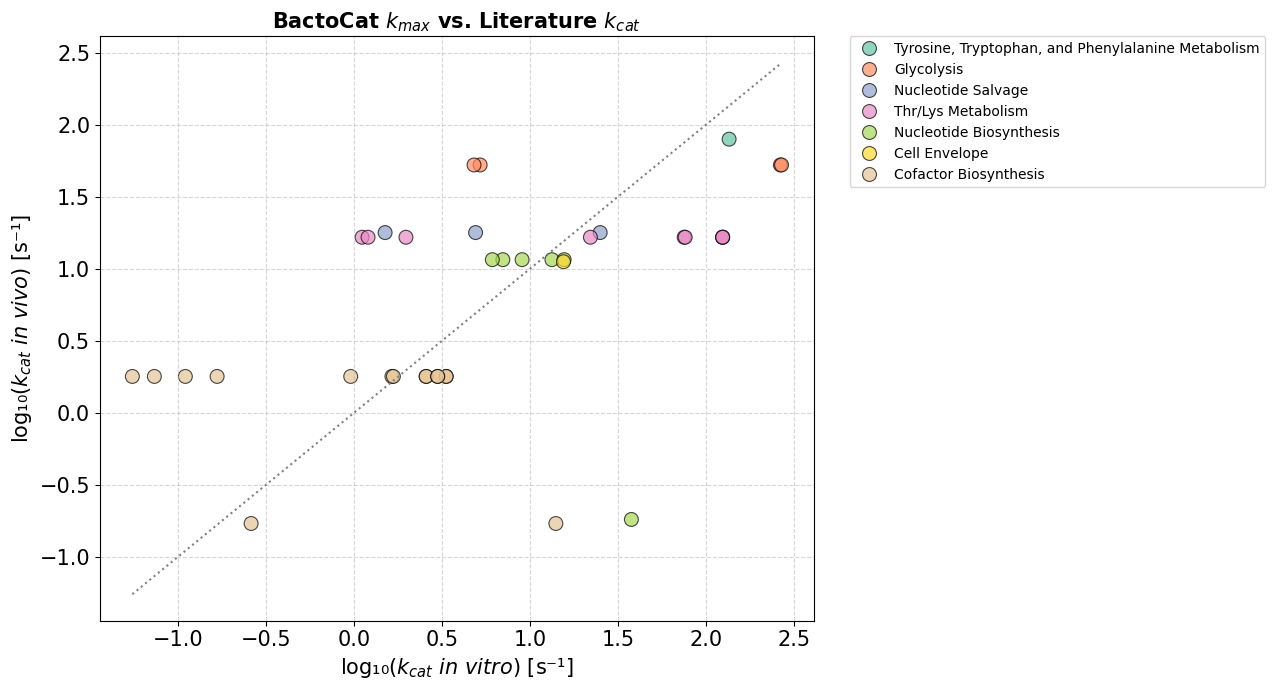

In [ ]:
## TODO: figure out the params

from src.plots import plot_scatter_kcat_kmax

plot_scatter_kcat_kmax(
    df=eta_df, 
    x_col='kcat_in_vitro', 
    y_col='kcat_app_max',       
    log_transform=True,
    hue_col='subsystem',
    title="BactoCat $k_{max}$ vs. Literature $k_{cat}$"
)

### 4.6 Inspect the Distribution of $k_{max}$ of Aida

Compare distributions between Aida in-vivo kcat and CatPred in-vitro kcat 


KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            kcat in vivo (Aida&Ying, filtered) kcat in vitro (CatPred)
--------------------------------------------------
Count                428             1,327          
Mean                 9.92e+03        7.23e+03       
Median               3.00e+01        1.43e+01       
Std Dev              8.34e+04        6.32e+04       
P10                  1.52e-01        1.20e-01       
P25                  1.55e+00        1.40e+00       
P75                  2.03e+02        9.20e+01       
P90                  2.14e+03        7.50e+02       
IQR (P25-P75)        2.01e+02        9.06e+01       
Geometric Mean       1.84e+01        1.19e+01       
Geometric Std        5.09e+01        3.60e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            kcat in vivo (Aida&Ying, filtered) kcat in vitro (CatPred)
----------

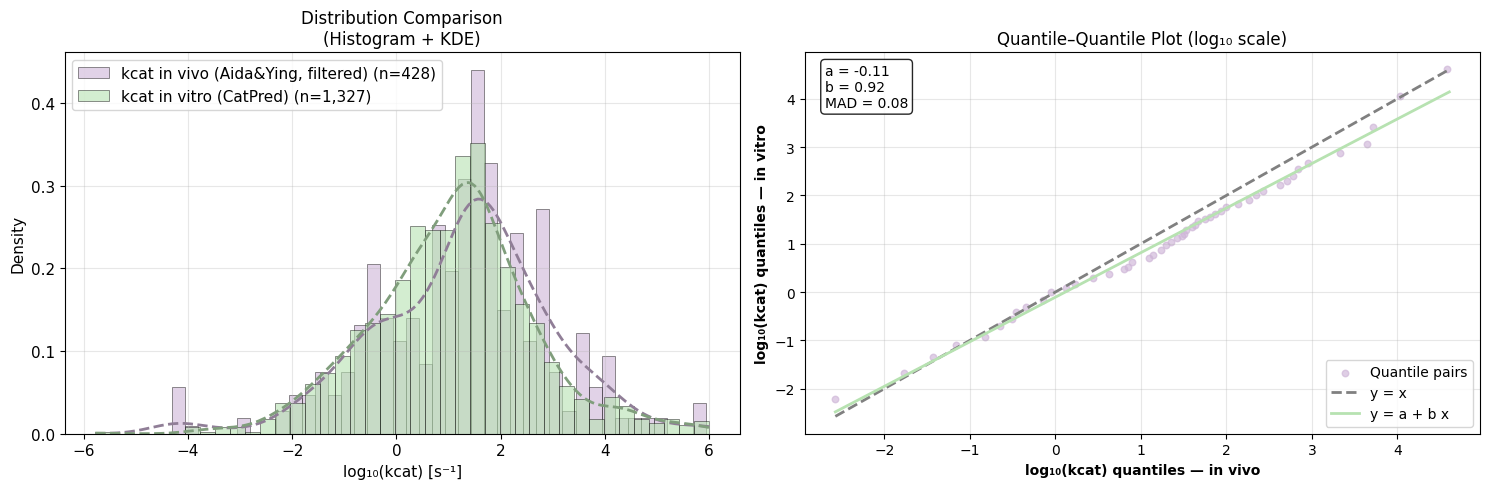

In [ ]:
from src.plots import compare_kcat_distribution

compare_kcat_distribution(aida_filtered_df, "kcat_app_max", df_catpred, "kcat_CatPred", 
                          label1="kcat in vivo (Aida&Ying, filtered)", label2="kcat in vitro (CatPred)")

Compare distributions between Aida in-vivo kcat and EnzyExtract in-vitro kcat 

KCAT DISTRIBUTION COMPARISON SUMMARY

ORIGINAL SCALE STATISTICS (s⁻¹)
--------------------------------------------------
Statistic            $k_{cat}$ $in$ $vivo$ $k_{cat}$ $in$ $vitro$
--------------------------------------------------
Count                428             8,643          
Mean                 9.92e+03        1.29e+04       
Median               3.00e+01        5.70e+00       
Std Dev              8.34e+04        4.71e+05       
P10                  1.52e-01        5.19e-02       
P25                  1.55e+00        4.60e-01       
P75                  2.03e+02        4.10e+01       
P90                  2.14e+03        2.28e+02       
IQR (P25-P75)        2.01e+02        4.05e+01       
Geometric Mean       1.84e+01        4.11e+00       
Geometric Std        5.09e+01        2.96e+01       

LOG₁₀ SCALE STATISTICS
--------------------------------------------------
Statistic            $k_{cat}$ $in$ $vivo$ $k_{cat}$ $in$ $vitro$
--------------------------------------

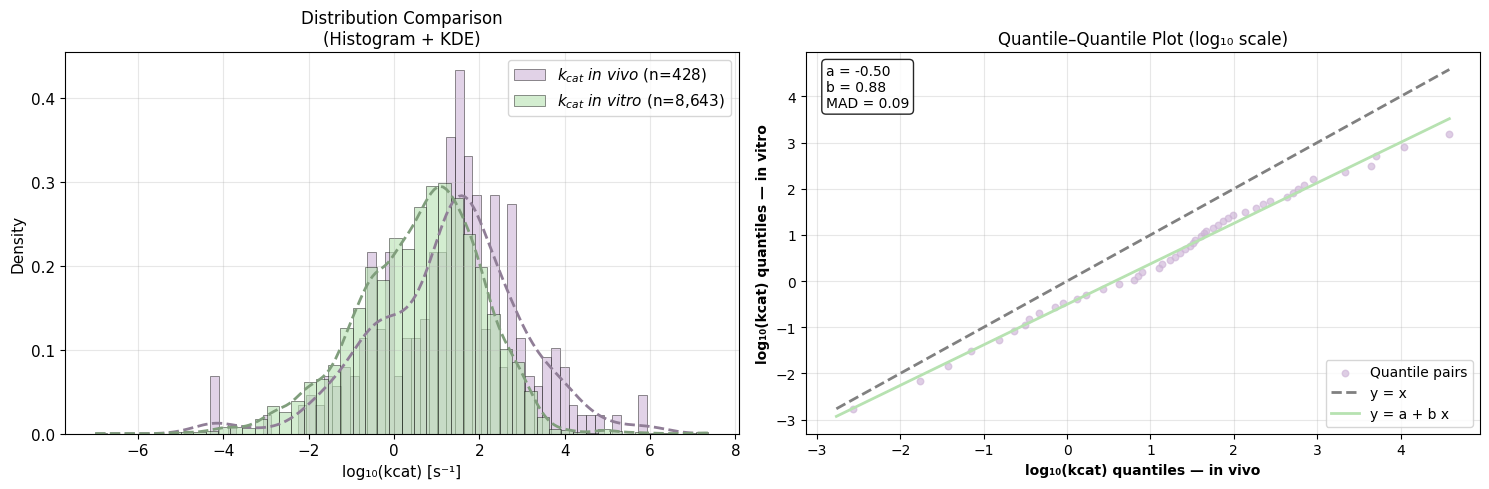

In [30]:
compare_kcat_distribution(aida_filtered_df, "kcat_app_max", df_enzyextract, "kcat_EnzyExtract", 
                          label1="$k_{cat}$ $in$ $vivo$", label2="$k_{cat}$ $in$ $vitro$")

### 4.7 Boxplot of eta values by subsystem

/home/yuxiz/BactoCat/src/plots.py:548: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['subsystem'] = df['subsystem'].replace({


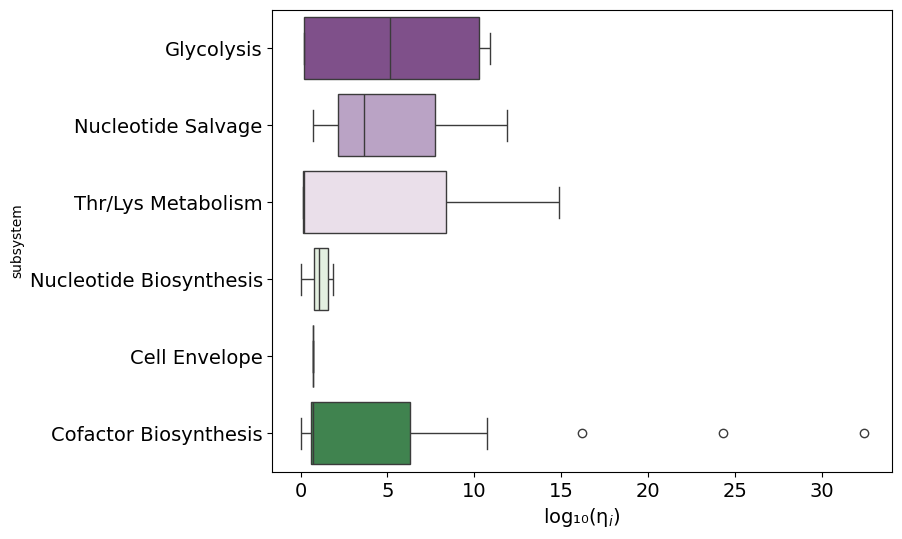

In [ ]:
from src.plots import plot_eta_by_subsystem

# TODO: correct? 
plot_eta_by_subsystem(eta_df, 'eta')

# Conclusion 

* BactoCat can successfully translate environmental conditions to kinetic parameters with biologically realistic distributions.
* Pathway-specific analysis revealed evolutionary strategies:
* Central carbon enzymes operate far below their theoretical maximum speeds. E. coli maintains an abundant, underutilized protein buffer to rapidly adapt to sudden nutrient shifts.
* Biosynthesis enzymes operate at or near their kinetic limits.
The cell synthesizes the minimum of these costly proteins,
pinpointing them as the primary targets for overexpression
in metabolic engineering to relieve pathway bottlenecks.